hERG blockers
Dataset Description: Human ether-à-go-go related gene (hERG) is crucial for the coordination of the heart's beating. Thus, if a drug blocks the hERG, it could lead to severe adverse effects. Therefore, reliable prediction of hERG liability in the early stages of drug design is quite important to reduce the risk of cardiotoxicity-related attritions in the later development stages.

Task Description: Binary classification. Given a drug SMILES string, predict whether it blocks (1) or not blocks (0).

Dataset Statistics: 648 drugs.

[1] Wang, Shuangquan, et al. “ADMET evaluation in drug discovery. 16. Predicting hERG blockers by combining multiple pharmacophores and machine learning approaches.” Molecular Pharmaceutics 13.8 (2016): 2855-2866.

In [1]:
# %% [code]

import sys
from pathlib import Path
import pandas as pd

# pour importer src/
sys.path.append("..")

# modules
from tdc.single_pred import Tox
from src.preprocessing import process_smiles, compute_ecfp4
from src.modeling      import split_data, train_sgd_classifier
from src.evaluation    import plot_roc_pr, compute_mcc, plot_calibration_curve
from src.preprocessing import plot_similarity_histogram

# chemins
DATA_DIR     = Path("data")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("✅ Imports OK")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found

✅ Imports OK


### - Chargement, Split et exploration du dataset hERG

In [2]:
# %% [code]
print("🔄 Chargement du jeu hERG via TDC…")
split = Tox(name='hERG').get_split()
train_df = split['train']
test_df  = split['test']
print(f"   ▶️ train_df shape: {train_df.shape}")
print(f"   ▶️ test_df  shape: {test_df.shape}")
train_df.head()


Found local copy...
Loading...
Done!


🔄 Chargement du jeu hERG via TDC…
   ▶️ train_df shape: (458, 3)
   ▶️ test_df  shape: (131, 3)


,Drug_ID,Drug,Y
0,DEMETHYLASTEMIZOLE,Oc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1,1.0
1,GBR-12909,Fc1ccc(C(OCC[NH+]2CC[NH+](CCCc3ccccc3)CC2)c2cc...,1.0
2,CLOFILIUM PHOSPHATE,CCCCCCC[N+](CC)(CC)CCCCc1ccc(Cl)cc1.CCCCCCC[N+...,1.0
3,FLUSPIRILENE,O=C1NCN(c2ccccc2)C12CC[NH+](CCCC(c1ccc(F)cc1)c...,1.0
4,VANOXERINE HYDROCHLORIDE,Fc1ccc(C(OCCN2CCN(CCCc3ccccc3)CC2)c2ccc(F)cc2)cc1,1.0


#### Processing SMILES

In [3]:
# %% [code]
print("🔄 Nettoyage des SMILES…")
# process_smiles retourne None pour les invalides
train_df['smiles_clean'] = train_df['Drug'].apply(process_smiles)
test_df ['smiles_clean'] = test_df ['Drug'].apply(process_smiles)

# on drop les invalides
n0 = len(train_df)
train_df = train_df.dropna(subset=['smiles_clean']).reset_index(drop=True)
print(f"   ▶️ train_df after cleaning: {len(train_df)} ({n0 - len(train_df)} removed)")

n1 = len(test_df)
test_df = test_df.dropna(subset=['smiles_clean']).reset_index(drop=True)
print(f"   ▶️ test_df  after cleaning: {len(test_df)} ({n1 - len(test_df)} removed)")


🔄 Nettoyage des SMILES…
   ▶️ train_df after cleaning: 458 (0 removed)
   ▶️ test_df  after cleaning: 131 (0 removed)


In [4]:
# %% [code]
print("🔄 Featurisation ECFP4…")
train_df['fp'] = train_df['smiles_clean'].apply(lambda s: compute_ecfp4(s, radius=2, nBits=2048))
test_df ['fp'] = test_df ['smiles_clean'].apply(lambda s: compute_ecfp4(s, radius=2, nBits=2048))

print(f"   ▶️ Exemple de fingerprint (len={len(train_df.loc[0,'fp'])} bits):")
print(train_df.loc[0,'fp'][:10], "...")  # affiche les 10 premiers bits


🔄 Featurisation ECFP4…
   ▶️ Exemple de fingerprint (len=2048 bits):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...


In [5]:
# %% [code]
print("🔄 Construction des tableaux X/y…")
X_train = pd.DataFrame(list(train_df['fp']))
y_train = train_df['Y'].astype(int)
X_test  = pd.DataFrame(list(test_df ['fp']))
y_test  = test_df ['Y'].astype(int)
print(f"   ▶️ X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"   ▶️ X_test  shape: {X_test.shape}, y_test  shape: {y_test.shape}")


🔄 Construction des tableaux X/y…
   ▶️ X_train shape: (458, 2048), y_train shape: (458,)
   ▶️ X_test  shape: (131, 2048), y_test  shape: (131,)


### Train / test

Colonnes disponibles : ['Drug_ID', 'Drug', 'Y']
Après renommage et dropna : 655 lignes restantes

-- SGD --
Metrics for Pipeline:
    accuracy: 0.702
   precision: 0.722
      recall: 0.922
          f1: 0.810
     roc_auc: 0.583
      pr_auc: 0.726
         mcc: 0.201


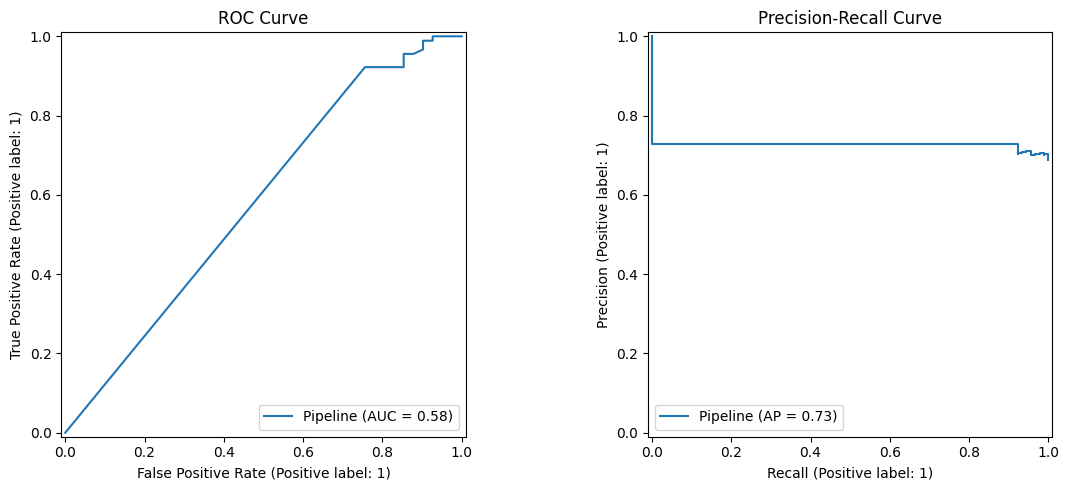


-- LogReg --
Metrics for Pipeline:
    accuracy: 0.748
   precision: 0.835
      recall: 0.789
          f1: 0.811
     roc_auc: 0.815
      pr_auc: 0.918
         mcc: 0.435


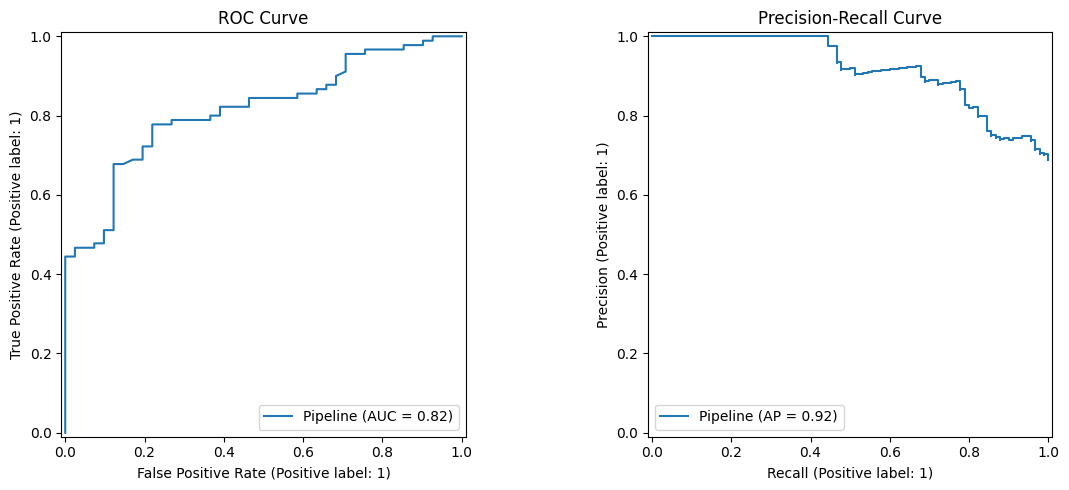


-- RF --
Metrics for RandomForestClassifier:
    accuracy: 0.824
   precision: 0.838
      recall: 0.922
          f1: 0.878
     roc_auc: 0.881
      pr_auc: 0.943
         mcc: 0.574


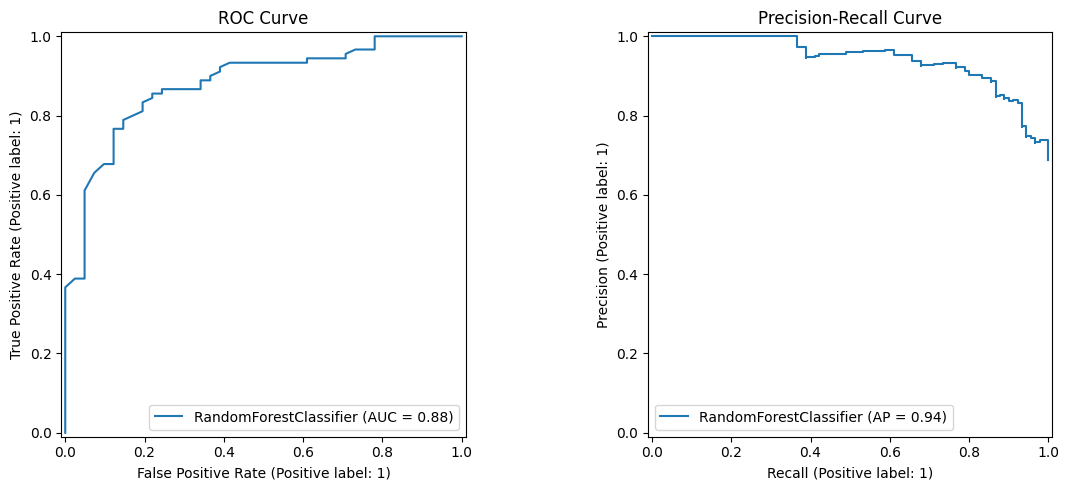


Feature importances:


1750    0.032519
1873    0.018962
926     0.011257
1380    0.009899
1171    0.009514
          ...   
1735    0.000000
995     0.000000
997     0.000000
998     0.000000
2047    0.000000
Length: 2048, dtype: float64


-- SVM --
Metrics for Pipeline:
    accuracy: 0.710
   precision: 0.710
      recall: 0.978
          f1: 0.822
     roc_auc: 0.805
      pr_auc: 0.889
         mcc: 0.206


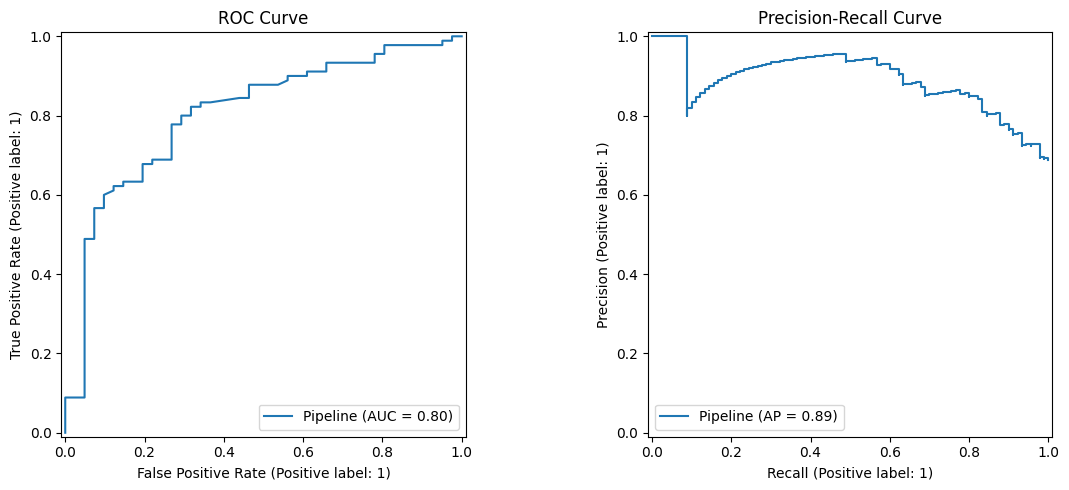

In [16]:
import pandas as pd

# 1) Lire le TSV
raw = pd.read_csv('data/herg.tab', sep='\t')
print("Colonnes disponibles :", raw.columns.tolist())

# 2) Supposons qu’elles s’appellent 'canonical_smiles' et 'herg_label'
#    Ajustez selon ce que print() vous affiche.
df = raw.rename(columns={
    'Drug': 'smiles',
    'Y':       'label'
})

# 3) Garder uniquement ces deux colonnes et nettoyer
df = df[['smiles','label']].dropna().reset_index(drop=True)
print(f"Après renommage et dropna : {df.shape[0]} lignes restantes")

# 4) On peut alors poursuivre :
from src.modeling import split_data, train_all_models, evaluate_model

X = pd.DataFrame(df['smiles'].apply(compute_ecfp4).tolist())  # ou votre pipeline de featurisation
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = split_data(X, y)
models = train_all_models(X_train, y_train)
for name, m in models.items():
    print(f"\n-- {name} --")
    evaluate_model(m, X_test, y_test, feature_names=X.columns.tolist())


##  Modèles et hyperparamètres

| Modèle                  | Description                                                                                                  | Hyperparamètres explorés (GridSearchCV)                        |
|-------------------------|--------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------|
| **SGDClassifier**       | Classifieur linéaire entraîné par descente de gradient stochastique.                                         | `loss='log_loss'`, `alpha∈{1e-4,1e-3}`, `penalty∈{'l2','elasticnet'}` |
| **LogisticRegression**  | Régression logistique classique, robuste et interprétable.                                                   | `solver='liblinear'`, `C∈{0.1,1.0,10.0}`                                 |
| **RandomForestClassifier** | Ensemble de forêts d’arbres de décision, réduit le sur‑apprentissage et capture les interactions non linéaires. | `n_estimators∈{100,200}`, `max_depth∈{None,5,10}`                      |
| **SVC (SVM)**           | Machine à vecteurs de support à noyau RBF, excellente pour les frontières complexes.                         | `kernel='rbf'`, `C∈{0.1,1.0}`, `gamma∈{'scale','auto'}`                |

---

##  Métriques d’évaluation

- **Accuracy**  
  \((TP+TN)/(TP+TN+FP+FN)\)  
  Proportion de prédictions correctes.  
  → utile pour un aperçu global, mais sensible au déséquilibre.

- **Precision**  
  \(TP/(TP+FP)\)  
  Parmi les positifs prédits, fraction de vrais positifs.  
  → important si les faux positifs sont coûteux.

- **Recall (Sensibilité)**  
  \(TP/(TP+FN)\)  
  Parmi les vrais positifs, fraction détectée.  
  → critique si les faux négatifs sont dangereux.

- **F1‑score**    
  Moyenne harmonique de Precision et Recall.  
  → bon compromis P/R.

- **ROC‑AUC**  
  Aire sous la courbe ROC (TPR vs FPR).  
  0.5 = aléatoire, 1 = parfait.  
  → 0.8–0.9 = bon, > 0.9 = excellent.

- **PR‑AUC**  
  Aire sous la courbe Precision‑Recall.  
  Plus informatif quand les positifs sont rares.

- **MCC (Matthews Corr. Coef.)**   
  Entre –1 et 1; robuste au déséquilibre.  
  → > 0.5 = très solide.  


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Metrics for RandomForestClassifier:
    accuracy: 0.779
   precision: 0.780
      recall: 0.944
          f1: 0.854
     roc_auc: 0.881
      pr_auc: 0.946
         mcc: 0.445


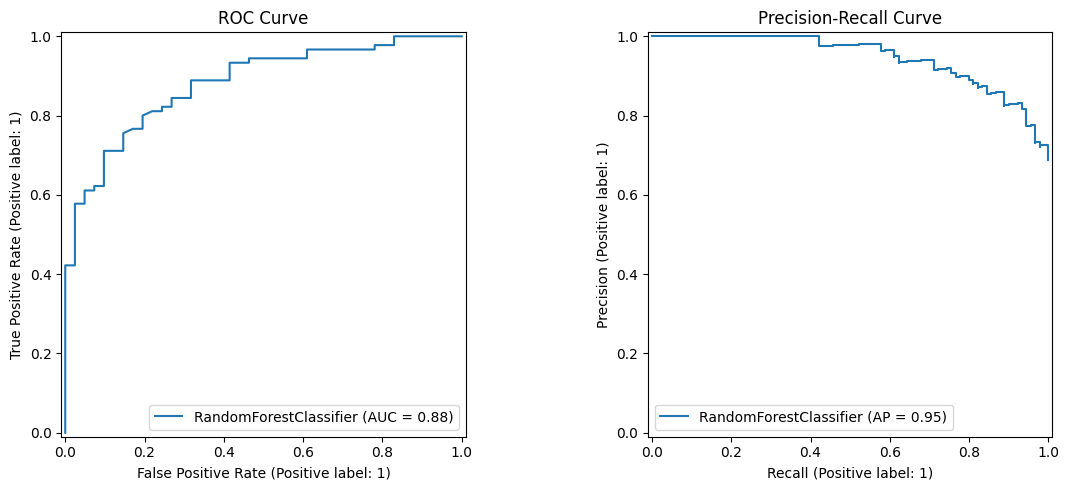


Feature importances:


1750    0.034129
1873    0.026217
1380    0.015731
1088    0.013115
1171    0.012190
          ...   
746     0.000000
741     0.000000
1770    0.000000
726     0.000000
2047    0.000000
Length: 2048, dtype: float64

{'accuracy': 0.7786259541984732,
 'precision': np.float64(0.7798165137614679),
 'recall': np.float64(0.9444444444444444),
 'f1': np.float64(0.8542713567839196),
 'roc_auc': np.float64(0.8810298102981029),
 'pr_auc': np.float64(0.945962573143495),
 'mcc': np.float64(0.4454286072985058)}

In [17]:
from src.modeling import train_rf_classifier

rf_param_grid = {
  'n_estimators': [100, 300, 500],
  'max_depth':    [None, 10, 20],
  'min_samples_split': [2,5,10]
}
best_rf = train_rf_classifier(X_train, y_train, param_grid=rf_param_grid)
evaluate_model(best_rf, X_test, y_test, feature_names=X.columns.tolist())


In [18]:
from src.modeling import save_model
save_model(best_rf, 'artifacts/rf_herg_final.pkl')


Model saved to artifacts/rf_herg_final.pkl


### Application sur tes candidats VS

### Visualisation des risques

Top 2 molécules à plus faible risque hERG :


,chembl_id,ic50,units,smiles,smiles_clean,fp,herg_prob,herg_pred
276,CHEMBL150,3.0,ug.mL-1,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,O=C1C(O)=C(C2=CC=C(O)C=C2)OC2=CC(O)=CC(O)=C12,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.306936,0
281,CHEMBL441343,10.0,ug.mL-1,O=C(O)c1ccc(O)cc1,O=C(O)C1=CC=C(O)C=C1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.355035,0


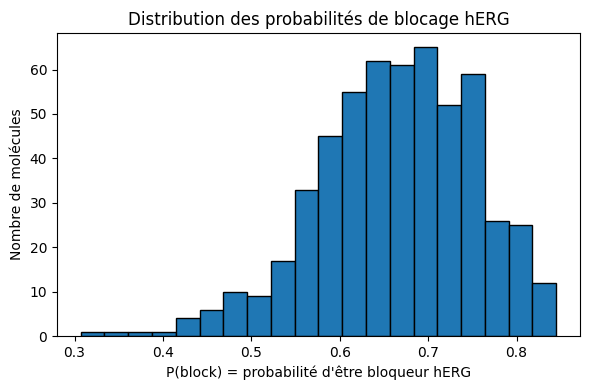

In [21]:
# %% [code]
import pandas as pd
from pathlib import Path
import joblib
from src.preprocessing import compute_ecfp4

# 0) Si tu n'as plus la variable `clf` en mémoire, recharge ton modèle :
#    clf = joblib.load("artifacts/RF_herg_model.pkl")

# 1) Charger ta liste de candidats post‑VS
ARTIFACT_DIR = Path("artifacts")
candidates = pd.read_pickle(ARTIFACT_DIR / "02_lib_filtered.pkl")

# 2) Calculer/mettre à jour les fingerprints
candidates["fp"] = candidates["smiles_clean"].apply(lambda s: compute_ecfp4(s))

# 3) Construire la matrice X
X_cand = pd.DataFrame(candidates["fp"].tolist())

# 4) Prédire avec ton classifieur 'clf'
#    -> probabilité d’être hERG‑bloqueur (classe 1)
candidates["herg_prob"] = best_rf.predict_proba(X_cand)[:,1]
candidates["herg_pred"] = best_rf.predict(X_cand)

# 5) Sélectionner les molécules à faible risque
low_risk = candidates[candidates["herg_prob"] < 0.50].sort_values("herg_prob")
print("Top 2 molécules à plus faible risque hERG :")
display(low_risk.head(2))

# %% [code]
import matplotlib.pyplot as plt

# 6) Visualiser la distribution des probabilités
plt.figure(figsize=(6,4))
plt.hist(candidates["herg_prob"], bins=20, edgecolor='black')
plt.title("Distribution des probabilités de blocage hERG")
plt.xlabel("P(block) = probabilité d'être bloqueur hERG")
plt.ylabel("Nombre de molécules")
plt.tight_layout()
plt.show()


Top 2 molécules à plus faible risque hERG :


,tki,MW,LogP,HBA,HBD,tanimoto_consensus,scaffold,smiles_clean,fp,herg_prob,herg_pred
chembl_id,,,,,,,,,,,


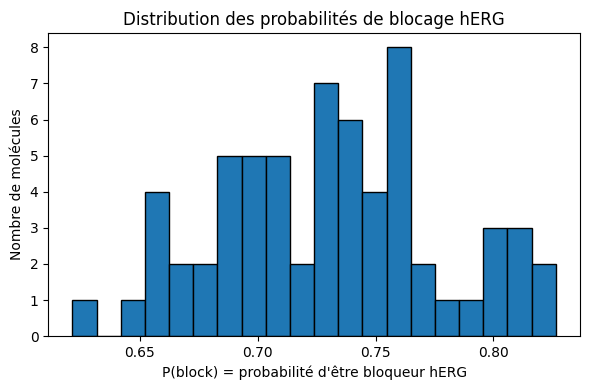

In [22]:
# %% [code]
candidates2 = pd.read_pickle(ARTIFACT_DIR / "04_consensus_detailed.pkl")

# 2) Calculer/mettre à jour les fingerprints
candidates2["fp"] = candidates2["smiles_clean"].apply(lambda s: compute_ecfp4(s))

# 3) Construire la matrice X
X_cand = pd.DataFrame(candidates2["fp"].tolist())

# 4) Prédire avec ton classifieur 'clf'
#    -> probabilité d’être hERG‑bloqueur (classe 1)
candidates2["herg_prob"] = best_rf.predict_proba(X_cand)[:,1]
candidates2["herg_pred"] = best_rf.predict(X_cand)

# 5) Sélectionner les molécules à faible risque
low_risk = candidates2[candidates2["herg_prob"] < 0.50].sort_values("herg_prob")
print("Top 2 molécules à plus faible risque hERG :")
display(low_risk.head(2))

# %% [code]
import matplotlib.pyplot as plt

# 6) Visualiser la distribution des probabilités
plt.figure(figsize=(6,4))
plt.hist(candidates2["herg_prob"], bins=20, edgecolor='black')
plt.title("Distribution des probabilités de blocage hERG")
plt.xlabel("P(block) = probabilité d'être bloqueur hERG")
plt.ylabel("Nombre de molécules")
plt.tight_layout()
plt.show()


Tous les hits trouvé dans 01 sont probable à un blocage du canal hERG

Columns: ['name', 'smiles']
Top 2 TKIs predicted to pose the lowest hERG risk:


,name,smiles,herg_prob,herg_pred
0,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,0.701093,1
2,Afatinib,CN(C)CC=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(...,0.704950,1
1,Gefitinib,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...,0.778503,1
3,Osimertinib,CN1C=C(C2=CC=CC=C21)C3=NC(=NC=C3)NC4=C(C=C(C(=...,0.801216,1


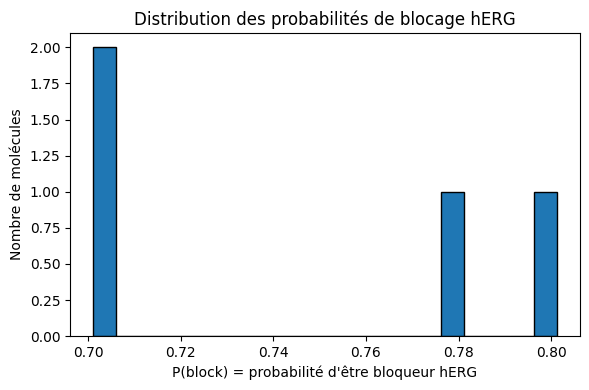

In [27]:
# %% [code]
import pandas as pd
from pathlib import Path
import joblib
from src.preprocessing import compute_ecfp4

# 1) Lire la liste des 4 TKIs
DATA_DIR = Path("data")
tkis = pd.read_csv(DATA_DIR / "tkis.csv")  
# Assure-toi que ton CSV contient bien une colonne 'smiles'
print("Columns:", tkis.columns.tolist())

# 2) Calculer les empreintes ECFP4
tkis["fp"] = tkis["smiles"].apply(compute_ecfp4)
# Supprimer les éventuels SMILES invalides
tkis = tkis.dropna(subset=["fp"]).reset_index(drop=True)

# 3) Déplier la liste de bits en colonnes numériques
X_tkis = pd.DataFrame(tkis["fp"].tolist())

# 4) Charger ton meilleur RF si besoin
# best_rf = joblib.load("artifacts/RF_herg_model.pkl")

# 5) Prédire proba et classes
tkis["herg_prob"] = best_rf.predict_proba(X_tkis)[:,1]
tkis["herg_pred"] = best_rf.predict(X_tkis)

# 6) Afficher les 2 molécules à plus faible risque
low = tkis.sort_values("herg_prob").head()
print("Top 2 TKIs predicted to pose the lowest hERG risk:")
display(low[["name","smiles","herg_prob","herg_pred"]])


plt.figure(figsize=(6,4))
plt.hist(tkis["herg_prob"], bins=20, edgecolor='black')
plt.title("Distribution des probabilités de blocage hERG")
plt.xlabel("P(block) = probabilité d'être bloqueur hERG")
plt.ylabel("Nombre de molécules")
plt.tight_layout()
plt.show()


Multiple cardiotoxicities during osimertinib therapy Kobat et al.

"Cardiotoxicities have been associated with a number of TKIs used in the treatment of lung cancer and can cause both treatment disruption and diminish quality of life.10–13 Cardiotoxic events that are attributed to the use of these TKIs include, but are not limited to, QTc prolongation, left ventricular dysfunction, heart failure, arrhythmia, ischaemia, myocardial infarction and fluctuations in blood pressure.13 The true incidence of cardiotoxicity associated with TKIs is potentially greater than that reported in clinical trial data due to a lack of systematic screening, risk assessment and monitoring."
